## Phase 1: Exploratory Data Analysis

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Load Data

In [2]:
df = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp,48204.0,281.205870,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,0.334264,44.789133,0.0,0.00,0.00,0.000,9831.30
snow_1h,48204.0,0.000222,0.008168,0.0,0.00,0.00,0.000,0.51
clouds_all,48204.0,49.362231,39.015750,0.0,1.00,64.00,90.000,100.00
traffic_volume,48204.0,3259.818355,1986.860670,0.0,1193.00,3380.00,4933.000,7280.00


In [5]:
print(df.shape)

(48204, 9)


In [6]:
df_copy = df.copy()

In [7]:
duplicates = df_copy.duplicated().sum()
print(f'There are {duplicates} duplicates')

There are 17 duplicates


In [8]:
df = df_copy.drop_duplicates()
print(df.shape)

(48187, 9)


* A total of 17 duplicate records were identified, representing less than 0.04% of the dataset. Since these duplicates were exact repetitions, they were removed to ensure data integrity without significantly affecting the dataset distribution.

In [9]:
missing_values = df_copy.isnull().sum()
print(missing_values)

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


### Target Variable Analysis

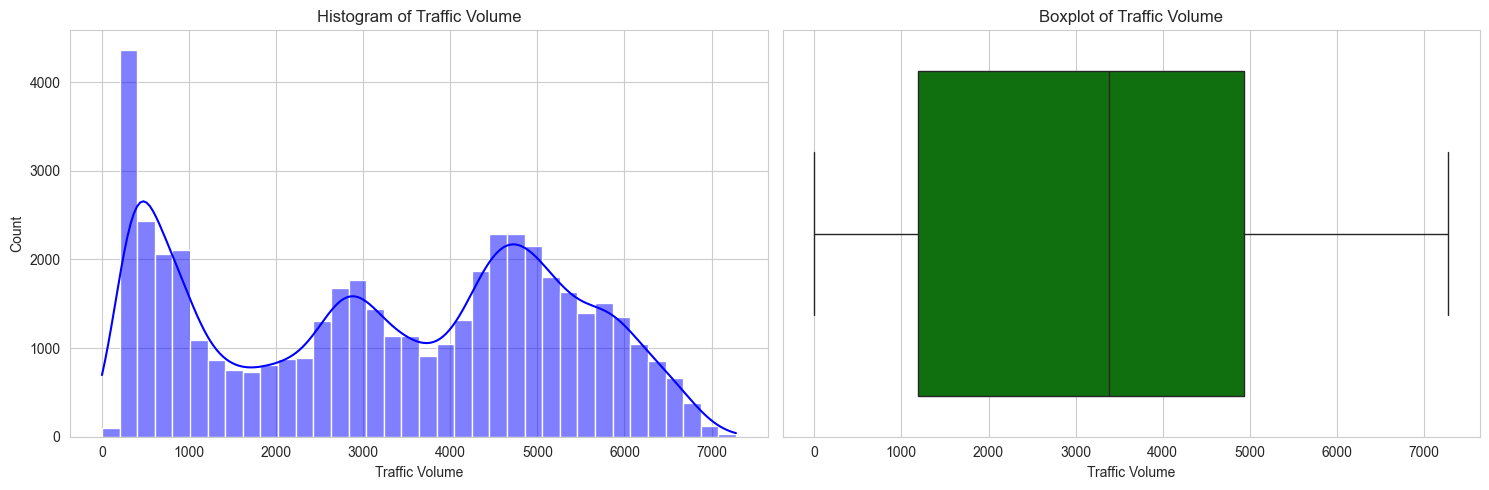

  Skewness: -0.09
  Kurtosis: -1.31


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(data=df_copy, x='traffic_volume', ax=axes[0], color='blue', kde=True)
axes[0].set_title('Histogram of Traffic Volume')
axes[0].set_xlabel('Traffic Volume')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(data=df_copy, x='traffic_volume', ax=axes[1], color = 'green')
axes[1].set_title('Boxplot of Traffic Volume')
axes[1].set_xlabel('Traffic Volume')

plt.tight_layout()
plt.show()

print(f"  Skewness: {df['traffic_volume'].skew():.2f}")
print(f"  Kurtosis: {df['traffic_volume'].kurt():.2f}")

#### Observations from Target Variable
* The `traffic_volume` variable has a skewness value of approximately -0.09, indicating that the distribution is nearly symmetric and approximately normally distributed.

* The kurtosis value of approximately -1.31 suggests a platykurtic distribution, meaning the distribution has lighter tails and a flatter peak compared to a normal distribution. This indicates a relatively lower likelihood of extreme outliers within the dataset.

### Missing Values Analysis

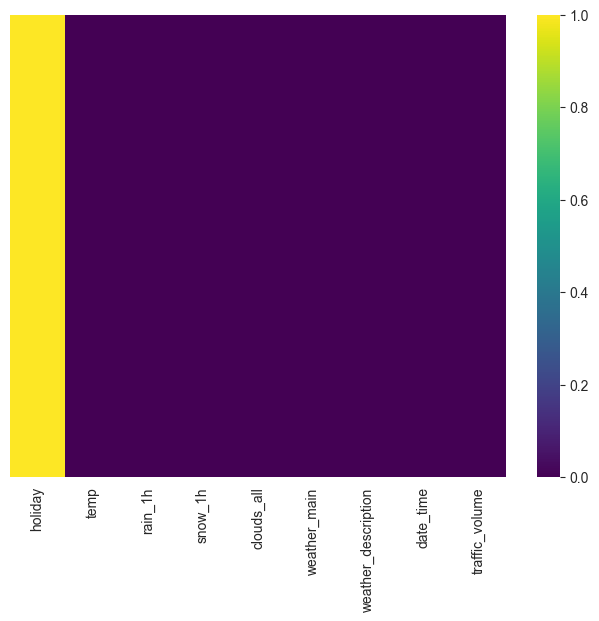

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_copy.isnull(), yticklabels=False, cmap='viridis')
plt.show()

- The missing values (48,143) present in the holiday column convey an important insight rather than indicating data quality issues. The absence of values suggests that most recorded days were non-holidays rather than missing observations.
- During preprocessing, the missing values will be imputed with the label NoHoliday to preserve the semantic meaning of the feature. 

### Numerical Columns Analyses

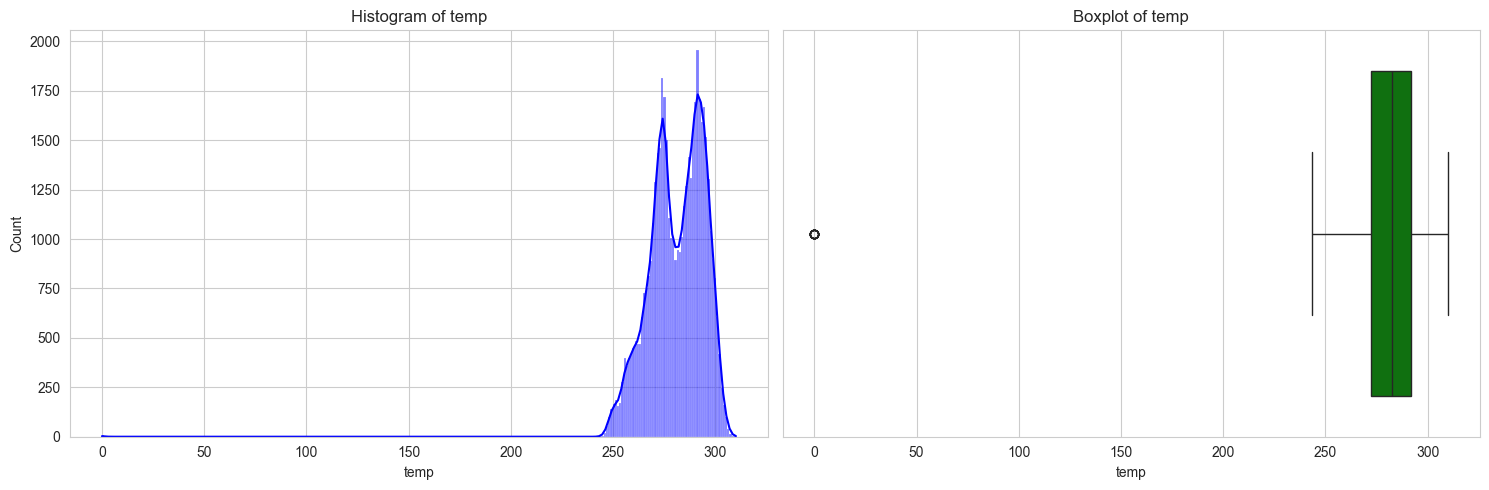

  Skewness: -2.25
  Kurtosis: 39.92


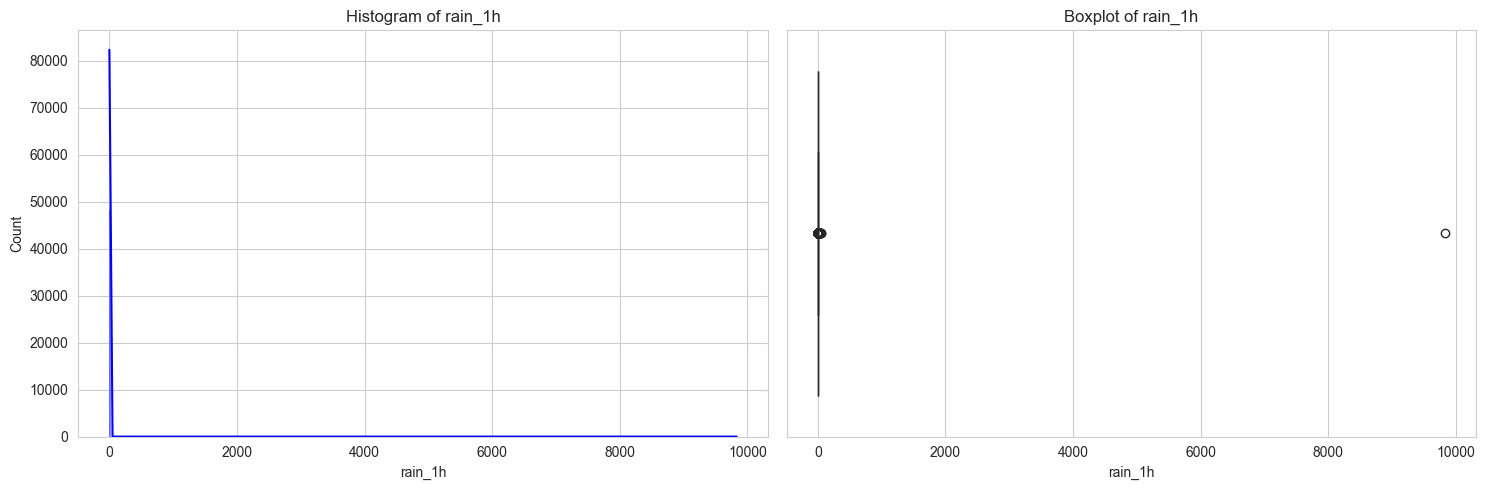

  Skewness: 219.35
  Kurtosis: 48138.64


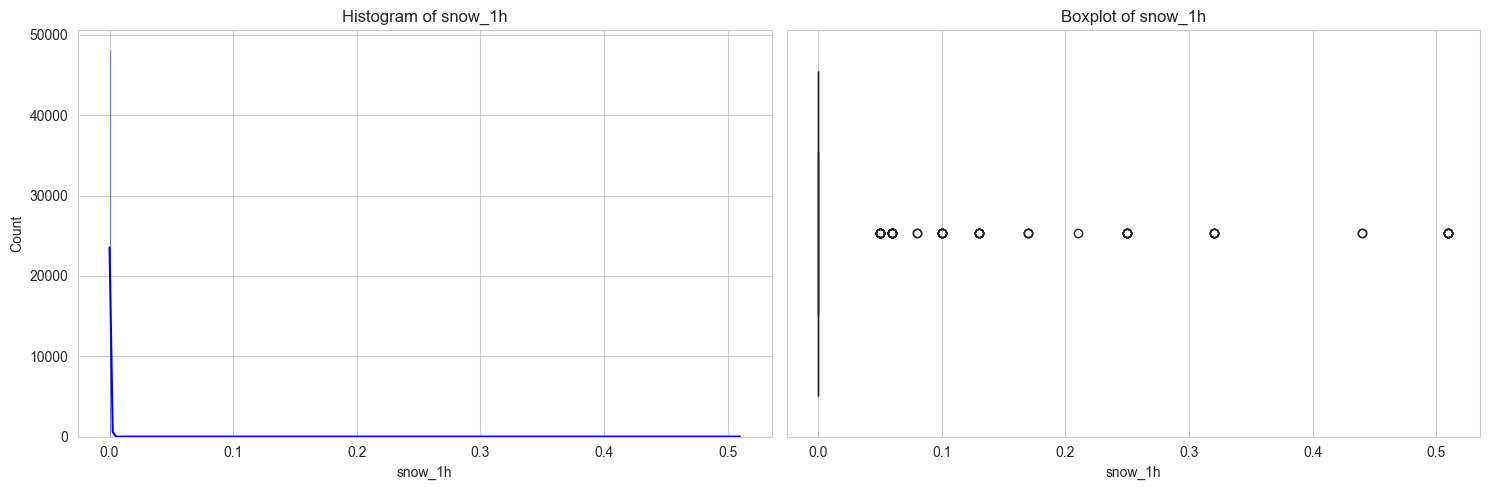

  Skewness: 48.36
  Kurtosis: 2619.54


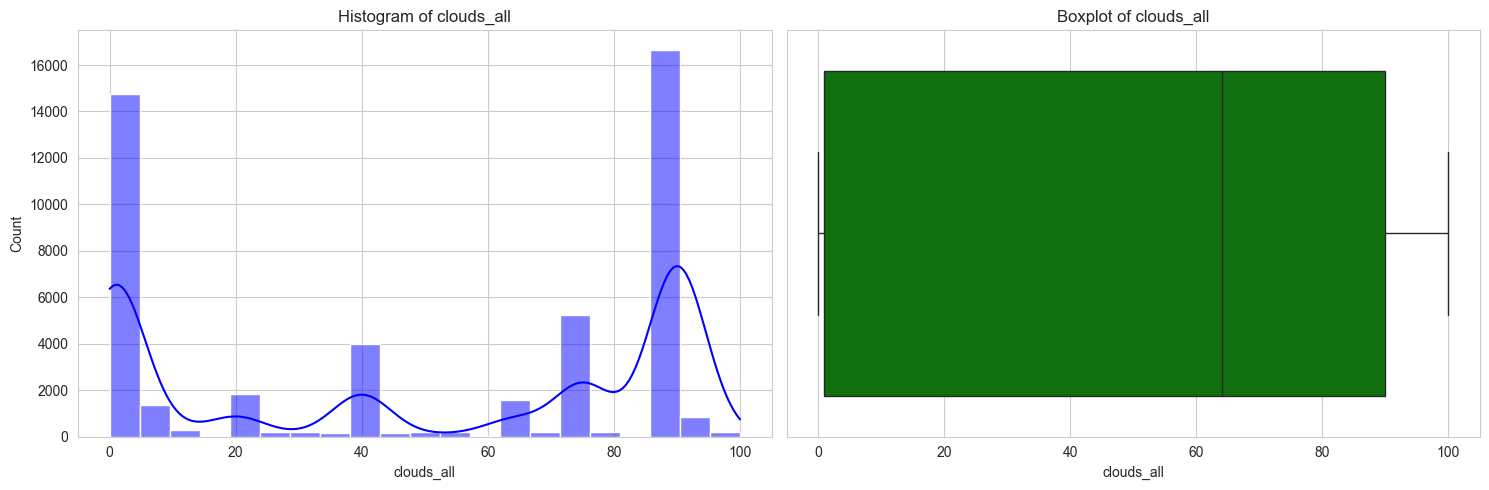

  Skewness: -0.20
  Kurtosis: -1.74


In [ ]:
numerical_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns.to_list()[:-1]

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(data=df_copy, x=col, ax=axes[0], color='blue', kde=True)
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    
    sns.boxplot(data=df_copy, x=col, ax=axes[1], color = 'green')
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurt():.2f}")

#### Observations from numerical columns
- The `temp` column contains approximately 10 observations with a value of 0. Since the temperature unit is recorded in Kelvin, a value of 0 K corresponds to absolute zero (-273.15°C), which is physically impossible under normal atmospheric conditions.
- Additionally, several of these observations are associated with weather descriptions such as sky is clear, further suggesting that these values are likely erroneous or improperly recorded missing values rather than valid measurements.
- To handle them, I'll be dropping the rows

* The `rain_1h` feature contains an extreme outlier with a value of approximately 9831.3. Assuming the unit represents millimeters of rainfall per hour, this value is physically unrealistic and significantly deviates from the general distribution of the dataset.
* Since typical hourly rainfall values are substantially lower, the observation is likely the result of a sensor malfunction, data entry issue, or recording anomaly rather than a genuine meteorological event.
Consequently, the outlier will be treated as an anomalous observation during preprocessing.



In [15]:
df_copy = df_copy[df_copy['temp'] != 0] 

In [16]:
df_copy = df_copy[df_copy['rain_1h'] < 1000]

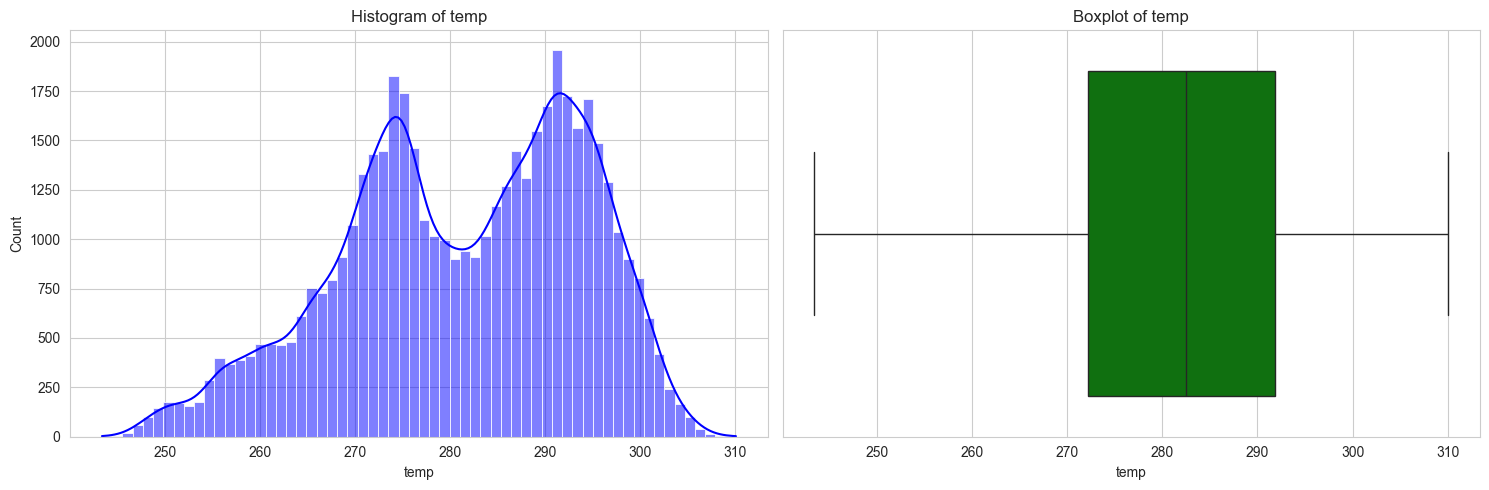

  Skewness: -2.25
  Kurtosis: 39.92


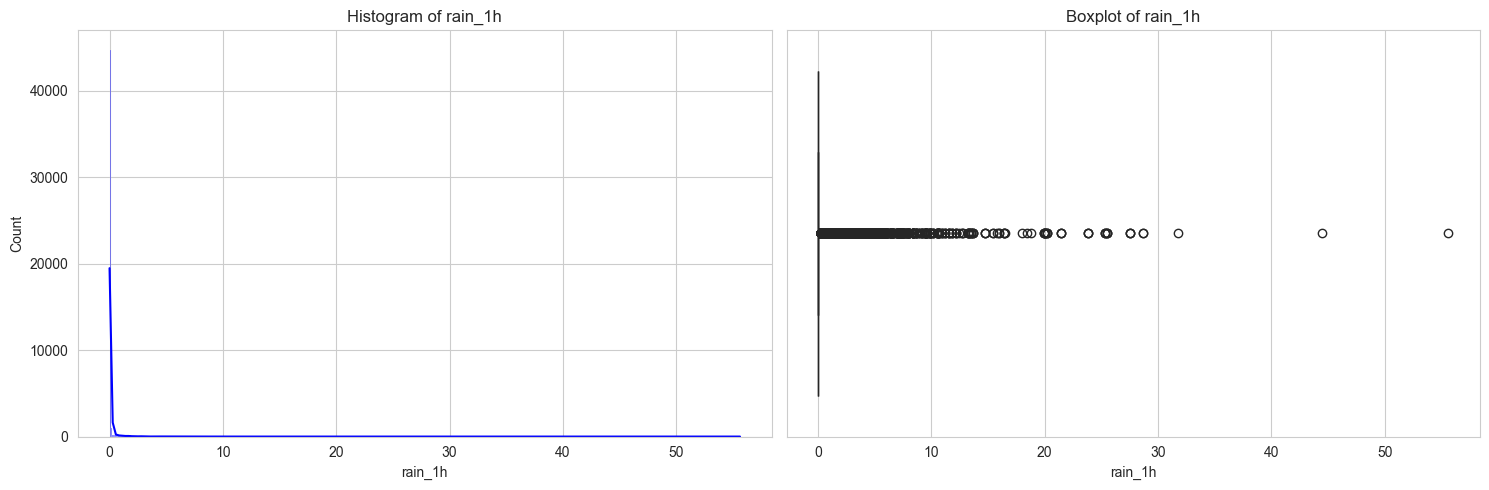

  Skewness: 219.35
  Kurtosis: 48138.64


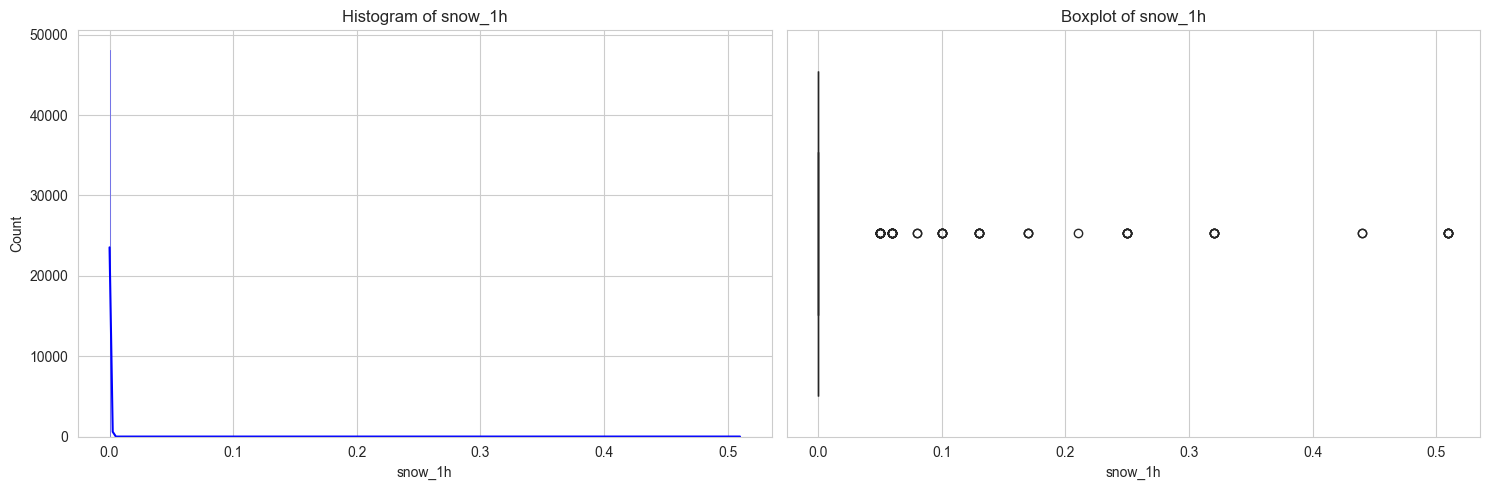

  Skewness: 48.36
  Kurtosis: 2619.54


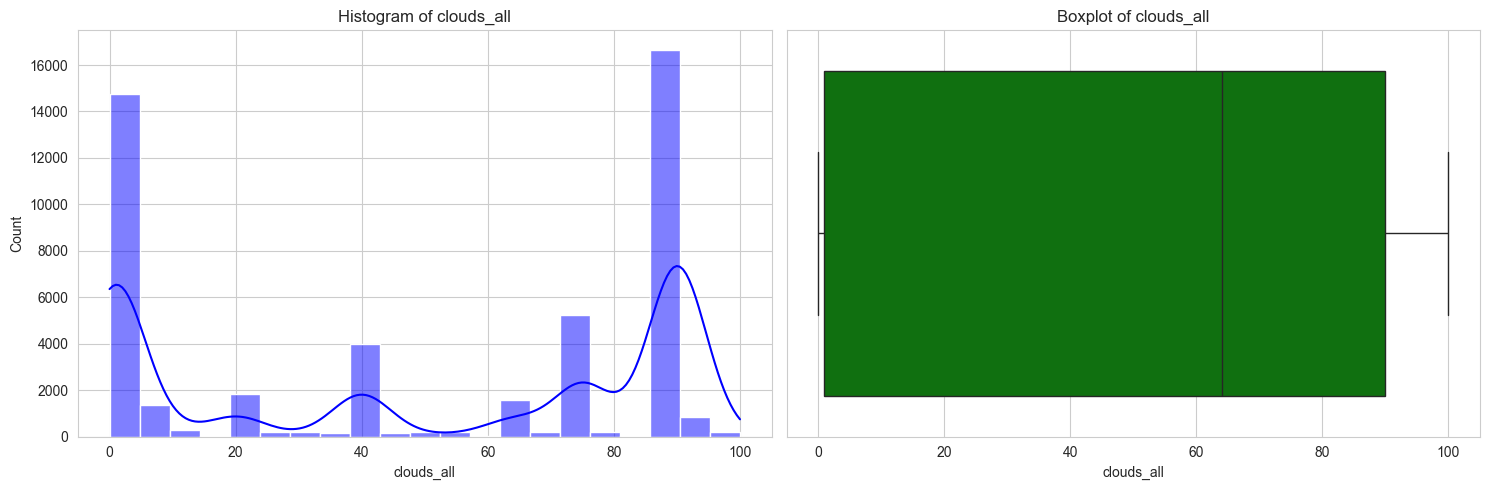

  Skewness: -0.20
  Kurtosis: -1.74


In [19]:
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(data=df_copy, x=col, ax=axes[0], color='blue', kde=True)
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    
    sns.boxplot(data=df_copy, x=col, ax=axes[1], color = 'green')
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurt():.2f}")

In [17]:
df_copy['date_time'] = pd.to_datetime(df_copy['date_time'])

### Categorical Columns Analysis

holiday:  11


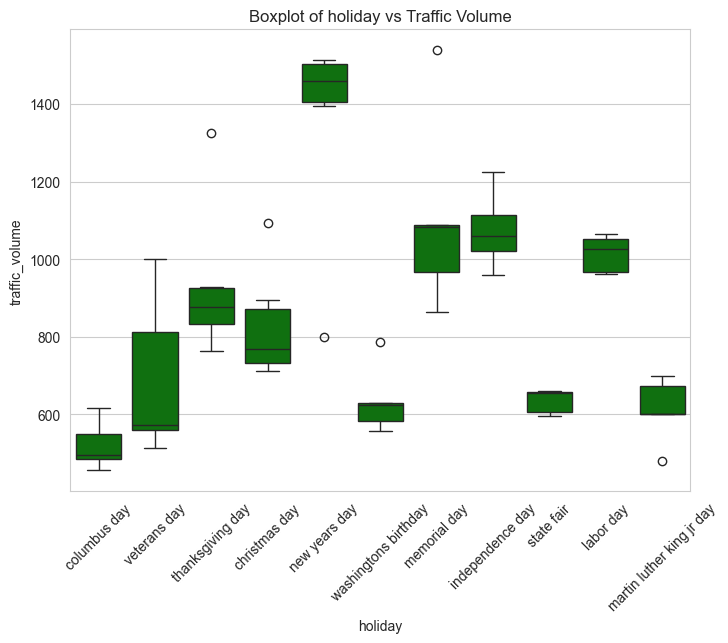

weather_main:  11


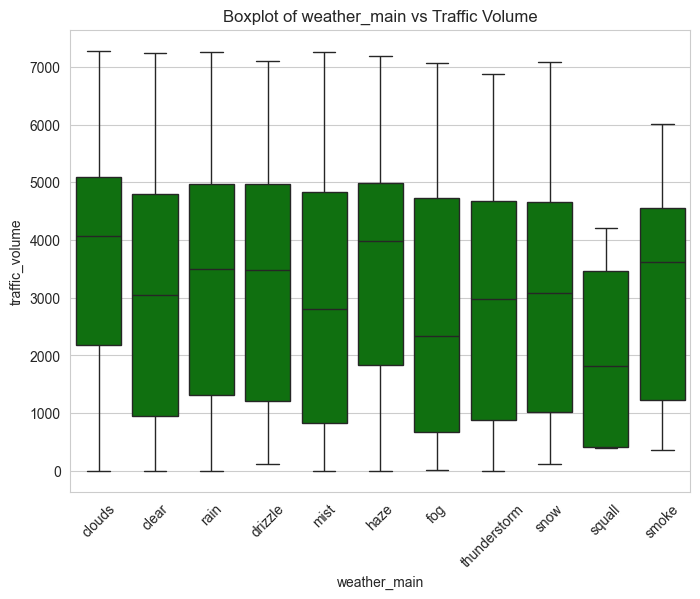

weather_description:  38


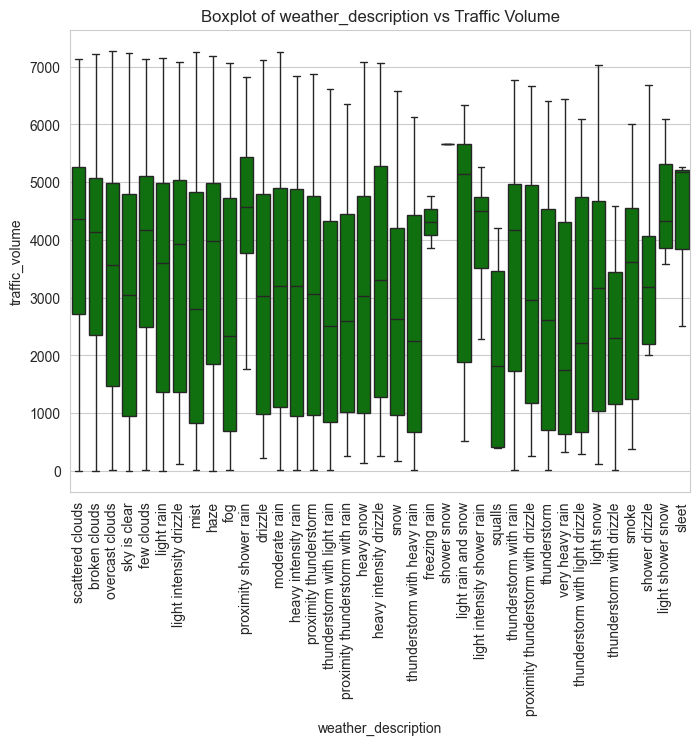

In [20]:
categorical_cols = df_copy.select_dtypes(include=['object']).columns.to_list()

for col in categorical_cols:
    print(f"{col}: ", df_copy[col].nunique())
    df_copy[col] = df_copy[col].str.lower().str.strip()
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_copy, x=col, y = 'traffic_volume', color = 'green')
    plt.title(f'Boxplot of {col} vs Traffic Volume')
    plt.xticks(rotation= 90 if col == 'weather_description' else 45)
    plt.show()

* The `holiday` feature appears to be a potentially strong predictor of traffic_volume, as noticeable differences exist in traffic patterns across the various holiday categories.

### Traffic by Hour

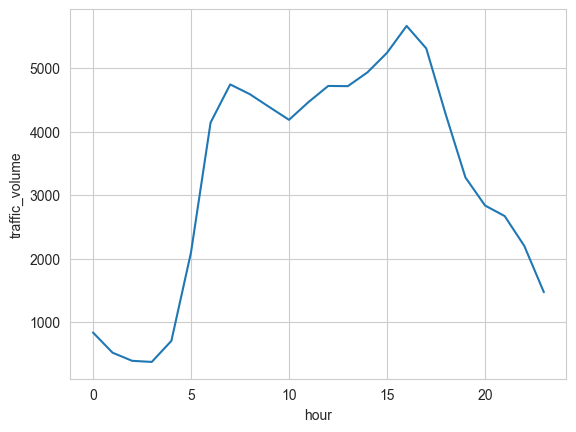

In [21]:
df_copy['hour'] = df_copy['date_time'].dt.hour

sns.lineplot(
    data=df_copy.groupby('hour')['traffic_volume'].mean().reset_index(),
    x='hour',
    y='traffic_volume'
)
plt.show()

- Analysis of the `traffic_volume by hour` reveals a clear temporal traffic pattern. Traffic volume remains relatively low during the early morning hours before increasing sharply around 06:00–07:00, indicating the beginning of rush-hour activity.
- Following the initial morning peak at approximately 07:00, traffic volume remains consistently high throughout the daytime period and gradually rises to its maximum peak around 16:00. After this point, traffic volume declines steadily into the late evening hours.

### Traffic by Weekday 

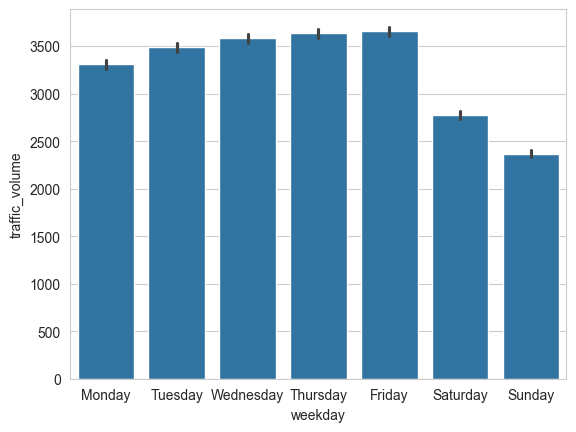

In [22]:
df_copy['weekday'] = df_copy['date_time'].dt.day_name()
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

sns.barplot(
    data=df_copy,
    x='weekday',
    y='traffic_volume',
    order=weekday_order
)
plt.show()

- Analysis of traffic volume across weekdays reveals a clear distinction between weekday and weekend traffic patterns. Traffic volume remains consistently high from Monday through Friday, with a gradual increase toward Friday, which records the highest average traffic volume.
- In contrast, traffic volume drops significantly during the weekend, particularly on Sunday, which exhibits the lowest average traffic volume among all days of the week.
- This pattern suggests that commuter and work-related activities strongly influence interstate traffic behavior, making temporal features such as `weekday` and `is_weekend` potentially important predictors for traffic volume estimation.

### Weekend 

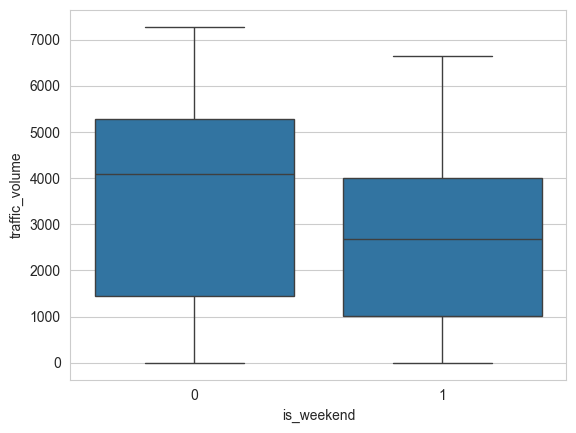

In [23]:
df_copy['is_weekend'] = df_copy['weekday'].isin(
    ['Saturday', 'Sunday']
).astype(int)

sns.boxplot(
    data=df_copy,
    x='is_weekend',
    y='traffic_volume'
)
plt.show()

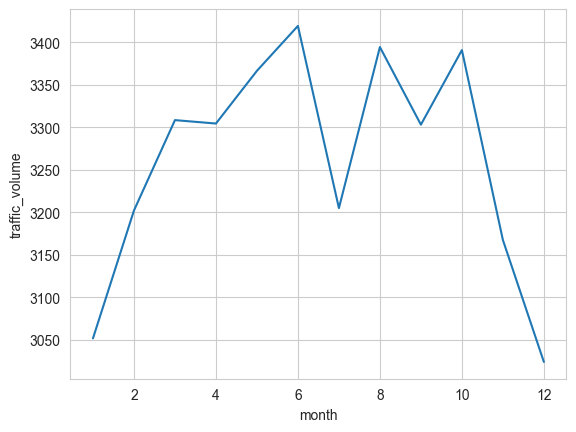

In [24]:
df_copy['month'] = df_copy['date_time'].dt.month

sns.lineplot(
    data=df_copy.groupby('month')['traffic_volume'].mean().reset_index(),
    x='month',
    y='traffic_volume'
)
plt.show()

* Analysis of traffic volume across different months reveals moderate seasonal variations in traffic behavior. Traffic volume generally increases from the beginning of the year and reaches higher levels during the mid-year months, particularly around June.
* Although fluctuations are observed throughout the year, the variation across months is less pronounced compared to the strong temporal patterns observed in hourly and weekday analyses.
* Additionally, traffic volume tends to decline toward the end of the year, with December recording one of the lowest average traffic volumes.
* These observations suggest that while seasonal effects may influence traffic behavior, short-term temporal factors such as hour of the day and day of the week likely exert a stronger influence on traffic volume.

### Key EDA Findings
1. Traffic volume is approximately normally distributed.
2. Holiday information appears influential on traffic behavior.
3. The dataset contains minimal duplicate records.
4. Temperature values of 0 K were identified as invalid observations.
5. An extreme rainfall outlier was detected and removed.
6. Missing values in holiday represent non-holiday days rather than data quality issues.
7. Traffic patterns appear likely to be strongly time-dependent.